### Import 
Potrzebujemy pobrać bibliotekę 'shap', reszta importowanych bibliotek powinna być juz pobrana w naszym kernelu

In [8]:
import shap
import xgboost as xgb
import pandas as pd
import optuna
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    classification_report
)
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/dataset_invoices.csv')
df.head(5)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,document_create_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,days_late,paid_late
0,U001,200769623,WAL-MAR corp,11.02.2020,2020,1930438491,25.01.2020,10.02.2020,USD,54273.28,26.01.2020,NAH4,1.930438e+09,0,1.0,1.0
1,U001,200980828,BEN E,08.08.2019,2019,1929646410,22.07.2019,11.08.2019,USD,79656.60,22.07.2019,NAD1,1.929646e+09,0,0.0,0.0
2,U001,200792734,MDV/ trust,30.12.2019,2019,1929873765,14.09.2019,29.09.2019,USD,2253.86,14.09.2019,NAA8,1.929874e+09,0,92.0,1.0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,30.03.2020,10.04.2020,CAD,3299.70,31.03.2020,CA10,2.960623e+09,1,NaN,NaN
4,U001,200769623,WAL-MAR foundation,25.11.2019,2019,1930147974,13.11.2019,28.11.2019,USD,33133.29,13.11.2019,NAH4,1.930148e+09,0,0.0,0.0


In [9]:
df.describe()

,buisness_year,doc_id,total_open_amount,invoice_id,isOpen,days_late,paid_late
count,50000.000000,5.000000e+04,50000.000000,4.999400e+04,50000.000000,40000.000000,40000.000000
mean,2019.305700,2.012238e+09,32337.021651,2.011340e+09,0.200000,2.708500,0.419100
std,0.460708,2.885235e+08,39205.975231,2.766335e+08,0.400004,9.096364,0.493418
min,2019.000000,1.928502e+09,0.720000,1.928502e+09,0.000000,0.000000,0.000000
25%,2019.000000,1.929342e+09,4928.312500,1.929342e+09,0.000000,0.000000,0.000000
50%,2019.000000,1.929964e+09,17609.010000,1.929964e+09,0.000000,0.000000,0.000000
75%,2020.000000,1.930619e+09,47133.635000,1.930619e+09,0.000000,2.000000,1.000000
max,2020.000000,9.500000e+09,668593.360000,2.960636e+09,1.000000,204.000000,1.000000


### Future engineering pod XGBoosta

In [10]:
target = df['paid_late']
df = df.sort_values('document_create_date').reset_index(drop=True)
df_clean = df.dropna(subset=['paid_late']).copy()
df_clean['paid_late'] = df_clean['paid_late'].astype(int)

df = df_clean.copy()

df['days_to_due'] = (
    pd.to_datetime(df['due_in_date'], format="%d.%m.%Y") - 
    pd.to_datetime(df['document_create_date'], format="%d.%m.%Y")
).dt.days

df['invoice_age'] = (
    pd.to_datetime(df['due_in_date'], format="%d.%m.%Y") - 
    pd.to_datetime(df['baseline_create_date'], format= "%d.%m.%Y")
).dt.days

df['doc_date'] = pd.to_datetime(
    df['document_create_date'], format='%d.%m.%Y')

#sortujemy po dacie aby uniknac data leakage
df = df.sort_values('doc_date').reset_index(drop=True)

df['avg_delay_customer'] = (
    df.groupby('cust_number')['days_late']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df['customer_late_rate'] = (
    df.groupby('cust_number')['paid_late']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df['customer_max_delay'] = (
    df.groupby('cust_number')['days_late']
    .transform(lambda x: x.shift(1).expanding().max())
)


df['customer_invoice_count'] = (
    df.groupby('cust_number')['invoice_id']
    .transform(lambda x: x.shift(1).expanding().count())
)
customer_avg_amount = df.groupby('cust_number')['total_open_amount'].transform('mean')
df['amount_vs_customer_avg'] = df['total_open_amount'] / (
    df.groupby('cust_number')['total_open_amount']
    .transform(lambda x: x.shift(1).expanding().mean())
)
df['invoice_month'] = pd.to_datetime(
    df['document_create_date'], format='%d.%m.%Y'
).dt.month

# enkodowanie zmiennych kategorycznych
le = LabelEncoder()
df['payment_terms_enc'] = le.fit_transform(
    df['cust_payment_terms'].astype(str)
)
df['currency_enc'] = le.fit_transform(
    df['invoice_currency'].astype(str)
)

# cechy do modelu
features = [
    'total_open_amount',
    'days_to_due',
    'invoice_age',
    'avg_delay_customer',
    'payment_terms_enc',
    'customer_late_rate',
    'customer_invoice_count',
    'customer_max_delay',
    'amount_vs_customer_avg',
    'invoice_month',
]


X = df[features].dropna()
target = df.loc[X.index, 'paid_late']

In [11]:
print(df['paid_late'].value_counts(dropna=False))
print(df['paid_late'].dtype)

paid_late
0    23236
1    16764
Name: count, dtype: int64
int64


### Trenowanie XGBoost'a

In [12]:
df['doc_date'] = pd.to_datetime(df['document_create_date'], format='%d.%m.%Y')
X_train = X[df['doc_date'] < '2019-07-01']
X_val = X[(df['doc_date'] >= '2019-07-01') & (df['doc_date'] < '2019-11-01')]
X_test = X[df['doc_date'] >= '2019-11-01']

y_train = target[df['doc_date'] < '2019-07-01']
y_val = target[(df['doc_date'] >= '2019-07-01') & (df['doc_date'] < '2019-11-01')]
y_test = target[df['doc_date'] >= '2019-11-01']

print(len(X_train), " - ilość faktur do treningu")
print(len(X_val), " - ilość faktur do walidacji")
print(len(X_test), " - ilość faktur do testu")

17358  - ilość faktur do treningu
12059  - ilość faktur do walidacji
9527  - ilość faktur do testu


/var/folders/rs/rx9snnk15ss4_d166y1sz82h0000gn/T/ipykernel_21819/3574652361.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X[df['doc_date'] < '2019-07-01']
/var/folders/rs/rx9snnk15ss4_d166y1sz82h0000gn/T/ipykernel_21819/3574652361.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val = X[(df['doc_date'] >= '2019-07-01') & (df['doc_date'] < '2019-11-01')]
/var/folders/rs/rx9snnk15ss4_d166y1sz82h0000gn/T/ipykernel_21819/3574652361.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test = X[df['doc_date'] >= '2019-11-01']


In [13]:
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          verbose=False)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=['na czas', 'po terminie']))


Accuracy:0.7150
ROC-AUC:0.7619
              precision    recall  f1-score   support

     na czas       0.74      0.82      0.78      5733
 po terminie       0.67      0.56      0.61      3794

    accuracy                           0.72      9527
   macro avg       0.70      0.69      0.69      9527
weighted avg       0.71      0.72      0.71      9527



## Uzycie Optuny aby uzyskać jak najlepsze wartości hiperparametrów

In [14]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# optuna - tuning na zbiorze walidacyjnym
def objective(trial):
    params = {
        'n_estimators': 300,
        'max_depth': 5,
        'subsample': 0.8,
        'colsample_bytree': 0.8, 
        'min_child_weight': 3,
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'auc'
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_proba)

optuna.logging.set_verbosity(optuna.logging.WARNING)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)

study = optuna.create_study(
    study_name="xgboost_tuning",
    storage="sqlite:///xgboost_optuna.db",
    direction='maximize',
    load_if_exists=True,
    pruner=pruner)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nNajlepszy ROC-AUC na walidacji: {study.best_value:.4f}")
print(f"Najlepsze parametry: {study.best_params}")


scale_pos_weight: 1.37


Best trial: 13. Best value: 0.82459: 100%|██████████| 30/30 [00:27<00:00,  1.10it/s]


Najlepszy ROC-AUC na walidacji: 0.8246
Najlepsze parametry: {'learning_rate': 0.017061598570293744}


Wykres przedstawia wazność hiperparametrów, wynika z niego ze n_estimators, subsample czy min_child_weight nie znacznie wpływa na końcowy wynik.
Mozemy sprowadzić wartości tych hiperparametrów do stałych aby zmniejszych ryzyko przeuczenia i przyspieszyć optymalizacje.

In [ ]:
### Finalny model z najlepszymi parametrami pod ROC-AUC

In [15]:
best_model = xgb.XGBClassifier(
    **study.best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=['na czas', 'po terminie']))

Accuracy:0.7398
ROC-AUC:0.8025
              precision    recall  f1-score   support

     na czas       0.77      0.82      0.79      5733
 po terminie       0.69      0.62      0.66      3794

    accuracy                           0.74      9527
   macro avg       0.73      0.72      0.72      9527
weighted avg       0.74      0.74      0.74      9527



In [16]:
import optuna

storage = optuna.storages.RDBStorage("sqlite:///xgboost_optuna.db")

#Lista wszystkich study w bazie
study_summaries = optuna.get_all_study_summaries(storage)
for s in study_summaries:
    print(f"Nazwa: {s.study_name}")
    print(f"  Liczba triali: {s.n_trials}")
    print(f"  Best value: {s.best_trial.value if s.best_trial else 'brak'}")

Nazwa: xgboost_tuning
  Liczba triali: 30
  Best value: 0.8245904445780887


In [17]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour,
    plot_parallel_coordinate
)

# Wczytaj study
study = optuna.load_study(
    study_name="xgboost_tuning",
    storage="sqlite:///xgboost_optuna.db"
)

# Podstawowe info
print(f"Best value: {study.best_value:.6f}")
print(f"Best params: {study.best_params}")



Best value: 0.824590
Best params: {'learning_rate': 0.017061598570293744}


In [18]:
import sys
!{sys.executable} -m pip install --force-reinstall nbformat

  Using cached nbformat-5.11.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached fastjsonschema-2.22.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached traitlets-5.16.1-py3-none-any.whl.metadata (10 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-2026.6.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached platformdirs-4.11.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached typing_extensions-4.16.0-py3-none-any.whl.metadata (3.3 kB)
Using cached nbformat-5.11.0-py3-none-any.whl (79 kB)
Using cached fastjsonschema-2.22.1-py3-none-any.whl (26 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-26.1.0-py3-none-any.whl 

In [19]:
import plotly.io as pio
pio.renderers.default = "vscode"  # lub "jupyterlab"
plot_optimization_history(study)


Mozemy zauwazyć, ze model bardzo szybko opytmalizuje się


Wykres przedstawia wazność hiperparametrów, wynika z niego ze n_estimators, subsample czy min_child_weight nie znacznie wpływa na końcowy wynik.
Mozemy sprowadzić wartości tych hiperparametrów do stałych aby zmniejszych ryzyko przeuczenia i przyspieszyć optymalizacje.

In [ ]:
plot_slice(study, params=["n_estimators", "subsample", "colsample_bytree"])

In [ ]:
plot_parallel_coordinate(study)

In [ ]:
import pandas as pd

trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values("value", ascending=False)
trials_df.head(10)  # top 10 triali

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_subsample,state
45,45,0.824852,2026-07-30 21:41:42.535080,2026-07-30 21:41:43.233640,0 days 00:00:00.698560,0.856414,0.028498,5,10,298,0.726826,COMPLETE
64,64,0.824800,2026-07-30 21:43:41.517246,2026-07-30 21:43:42.035449,0 days 00:00:00.518203,0.896130,0.044994,5,10,220,0.697012,COMPLETE
183,183,0.824772,2026-07-30 22:07:17.229001,2026-07-30 22:07:18.351690,0 days 00:00:01.122689,0.895372,0.025489,5,5,275,0.663371,COMPLETE
117,117,0.824730,2026-07-30 22:03:25.474648,2026-07-30 22:03:26.418236,0 days 00:00:00.943588,0.876193,0.022592,5,4,299,0.634289,COMPLETE
247,247,0.824604,2026-08-06 18:19:40.768679,2026-08-06 18:19:41.636121,0 days 00:00:00.867442,0.905876,0.021523,5,5,275,0.674803,COMPLETE
153,153,0.824588,2026-07-30 22:06:39.009829,2026-07-30 22:06:41.733103,0 days 00:00:02.723274,0.893454,0.021865,5,5,498,0.638128,COMPLETE
248,248,0.824581,2026-08-06 18:19:41.645192,2026-08-06 18:19:42.625528,0 days 00:00:00.980336,0.914689,0.019310,5,5,274,0.686656,COMPLETE
123,123,0.824557,2026-07-30 22:03:30.977024,2026-07-30 22:03:31.929083,0 days 00:00:00.952059,0.842622,0.026606,5,5,276,0.642317,COMPLETE
110,110,0.824555,2026-07-30 22:03:19.270618,2026-07-30 22:03:20.154654,0 days 00:00:00.884036,0.877070,0.022558,5,5,290,0.667734,COMPLETE
139,139,0.824555,2026-07-30 22:03:44.760171,2026-07-30 22:03:45.655908,0 days 00:00:00.895737,0.924862,0.022254,5,6,301,0.676981,COMPLETE


# Róznice pomiedzy zwykłym treningiem a treningiem z wykorzystaniem Optuny
### przed uzyciem Optuny

Accuracy:0.7245

ROC-AUC:0.7613
|   |precision  |  recall | f1-score  | support|
|---|-------|---------|---------|--------|
|na czas    |   0.72    |  0.88    |  0.79  |    5733|
|po terminie     |  0.73   |   0.49   |   0.59  |    3794|

### Po uzyciu Optuny
Accuracy:0.7433

ROC-AUC:0.8038
|    | precision  |  recall  |f1-score  | support |
|-----|--------|----------|---------|----------|
|na czas    |   0.76    |  0.83    |  0.80   |   5733 |
|po terminie   |    0.70   |   0.62    |  0.66   |   3794 |


### Wykresy SHAP'a

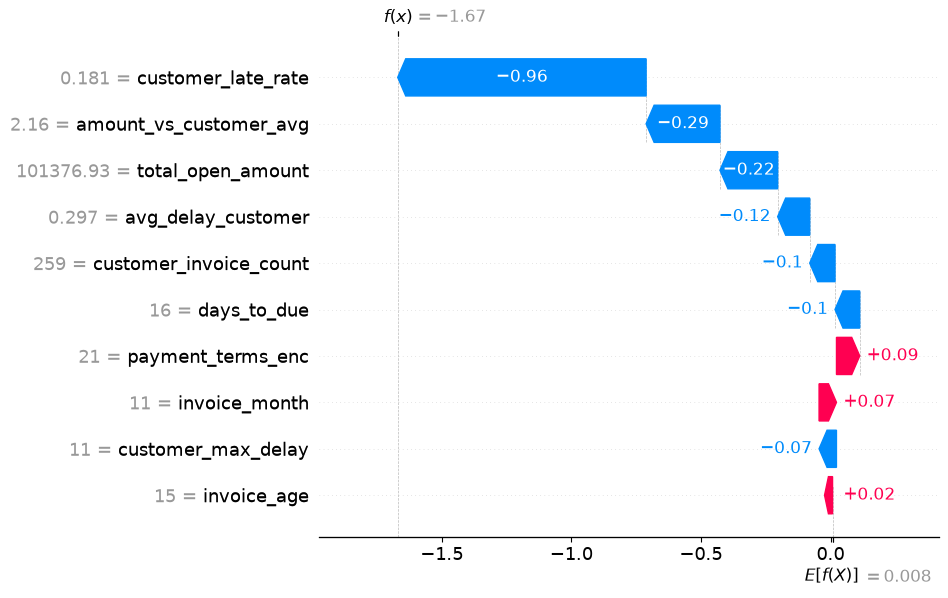

In [ ]:
# SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

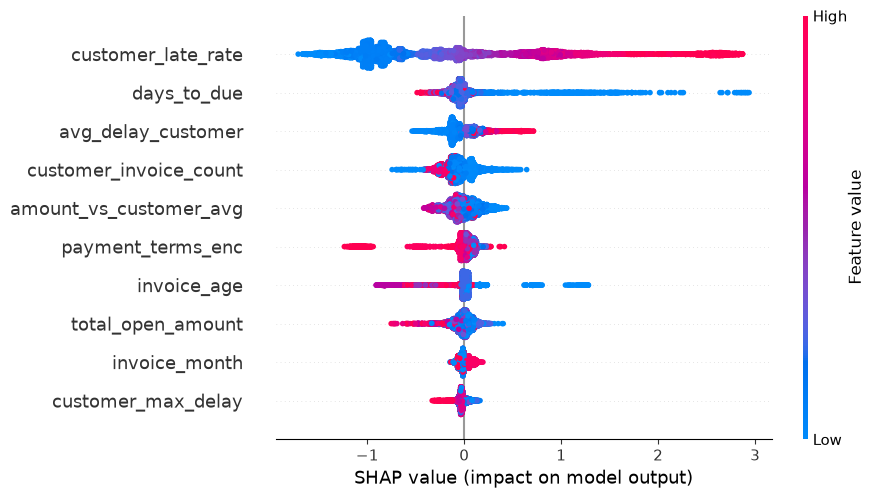

In [ ]:
shap.plots.beeswarm(shap_values)


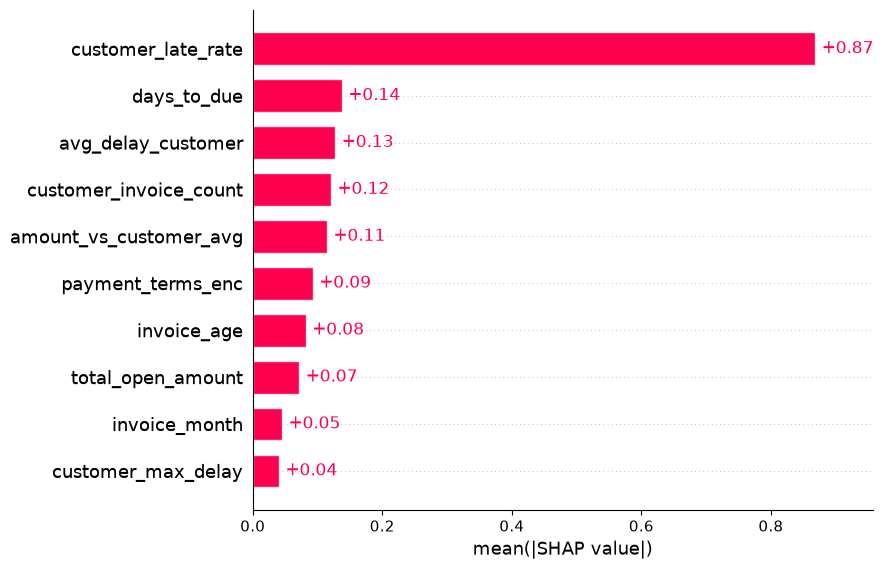

In [ ]:
shap.plots.bar(shap_values)